# 04 - Amelioration du Modele
Transfer Learning avec ResNet18 + Augmentation renforcee

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4  # Plus petit pour le fine-tuning

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Augmentation Renforcee

In [3]:
# Augmentation plus aggressive pour reduire l'overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(15),  # Plus de rotation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Translation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Variation luminosite
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Charger le dataset complet d'entrainement
full_train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=train_transform)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=test_transform)

# Creer un vrai validation set (15% du train) avec split stratifie
train_indices, val_indices = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.15,
    stratify=[full_train_dataset.targets[i] for i in range(len(full_train_dataset))],
    random_state=42
)

# Creer les subsets
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset_no_aug = datasets.ImageFolder(DATA_DIR / 'train', transform=test_transform)
val_dataset = Subset(val_dataset_no_aug, val_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images (15% du train original)")
print(f"Test: {len(test_dataset)} images")

# Compter les classes pour les poids
train_labels = [full_train_dataset.targets[i] for i in train_indices]
train_counts = {'NORMAL': train_labels.count(0), 'PNEUMONIA': train_labels.count(1)}
print(f"\nRepartition train: {train_counts}")

Train: 4433 images
Val: 783 images (15% du train original)
Test: 624 images

Repartition train: {'NORMAL': 1140, 'PNEUMONIA': 3293}


## 2. Transfer Learning - ResNet18

In [4]:
# Charger ResNet18 pre-entraine sur ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Geler les couches convolutives (optionnel - on peut aussi tout fine-tuner)
for param in model.parameters():
    param.requires_grad = False

# Remplacer la derniere couche pour classification binaire
# Pas de Sigmoid ici - on utilise BCEWithLogitsLoss
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
    # Pas de Sigmoid!
)

model = model.to(device)

# Compter les parametres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametres totaux: {total_params:,}")
print(f"Parametres entrainables: {trainable_params:,}")

Parametres totaux: 11,308,097
Parametres entrainables: 131,585


In [5]:
# Calculer les poids des classes pour gerer le desequilibre
pos_weight = torch.tensor([train_counts['NORMAL'] / train_counts['PNEUMONIA']])
print(f"Poids positif (pos_weight): {pos_weight.item():.4f}")

# Loss avec poids - BCEWithLogitsLoss (plus stable)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer - seulement la derniere couche
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

print(f"\nLoss: BCEWithLogitsLoss (avec pos_weight)")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")

Poids positif (pos_weight): 0.3462

Loss: BCEWithLogitsLoss (avec pos_weight)
Optimizer: Adam (lr=0.0001)


## 3. Fonctions d'entrainement avec Early Stopping

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)  # Logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)  # Convertir en probabilites
        predicted = (probs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)  # Logits
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)  # Convertir en probabilites
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / total, correct / total

In [7]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

## 4. Entrainement

In [8]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = Path('../outputs/checkpoints/best_resnet18.pt')
early_stopping = EarlyStopping(patience=5)

print(f"Entrainement ResNet18 sur {EPOCHS} epochs...")
print("=" * 60)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | BEST")
    else:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if early_stopping(val_loss):
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("=" * 60)
print(f"Meilleure Val Accuracy: {best_val_acc:.4f}")

Entrainement ResNet18 sur 10 epochs...


Epoch  1/10 | Train Loss: 0.2608 | Train Acc: 0.7961 | Val Loss: 0.1909 | Val Acc: 0.7765 | BEST


Epoch  2/10 | Train Loss: 0.1794 | Train Acc: 0.8674 | Val Loss: 0.1493 | Val Acc: 0.8314 | BEST


Epoch  3/10 | Train Loss: 0.1509 | Train Acc: 0.8856 | Val Loss: 0.1091 | Val Acc: 0.8927 | BEST


Epoch  4/10 | Train Loss: 0.1359 | Train Acc: 0.8947 | Val Loss: 0.1117 | Val Acc: 0.8876


...

Epoch  6/10 | Train Loss: 0.1313 | Train Acc: 0.8985 | Val Loss: 0.0880 | Val Acc: 0.9119 | BEST


Epoch  7/10 | Train Loss: 0.1183 | Train Acc: 0.9089 | Val Loss: 0.0890 | Val Acc: 0.9068


Epoch  8/10 | Train Loss: 0.1165 | Train Acc: 0.9089 | Val Loss: 0.0972 | Val Acc: 0.8966


Epoch  9/10 | Train Loss: 0.1020 | Train Acc: 0.9233 | Val Loss: 0.1172 | Val Acc: 0.8761


Epoch 10/10 | Train Loss: 0.1084 | Train Acc: 0.9186 | Val Loss: 0.0965 | Val Acc: 0.8940
Meilleure Val Accuracy: 0.9119


## 5. Courbes d'entrainement

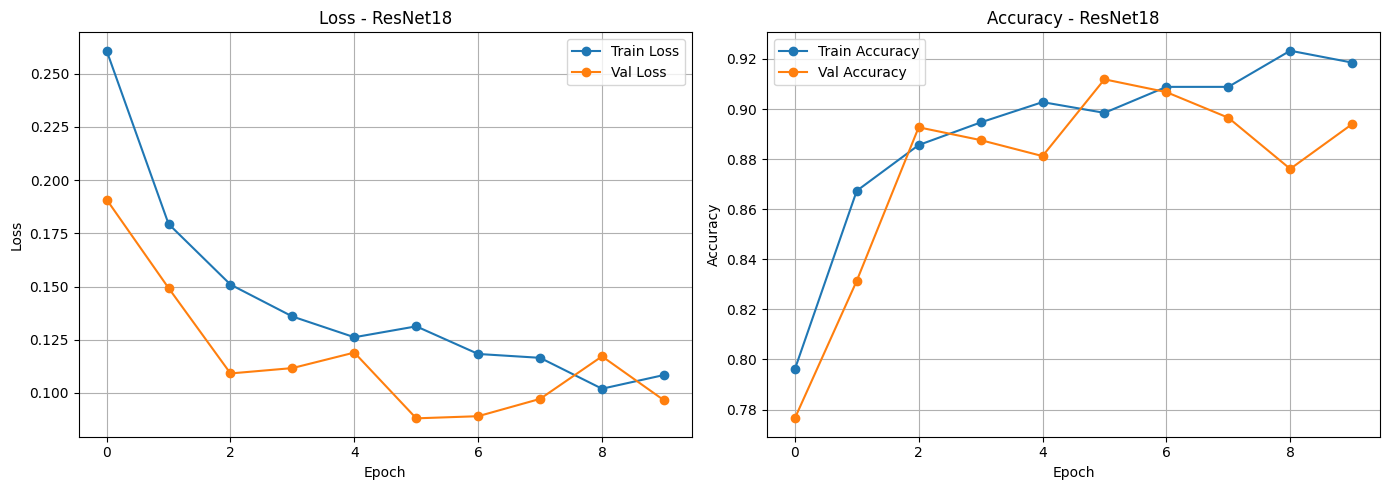

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss - ResNet18')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy - ResNet18')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/training_curves_resnet18.png', dpi=150)
plt.show()

## 6. Evaluation sur Test Set

In [10]:
# Charger le meilleur modele
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

# Predictions
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)  # Logits
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()  # Convertir en probabilites
        preds = (probs > 0.5).astype(float)
        
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        all_preds.extend(preds)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

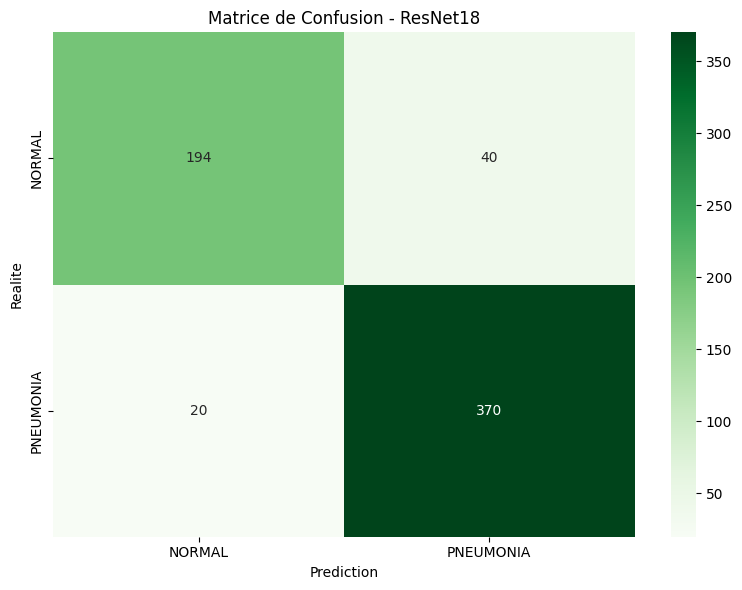

TN: 194 | FP: 40 | FN: 20 | TP: 370


In [11]:
# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Realite')
ax.set_title('Matrice de Confusion - ResNet18')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_resnet18.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")

In [12]:
# Metriques
print("=" * 60)
print("RAPPORT DE CLASSIFICATION - ResNet18")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 60)
print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f} <- Sensibilite")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score:    {f1:.4f}")

RAPPORT DE CLASSIFICATION - ResNet18
              precision    recall  f1-score   support

      NORMAL       0.91      0.83      0.87       234
   PNEUMONIA       0.90      0.95      0.93       390

    accuracy                           0.90       624
   macro avg       0.90      0.89      0.90       624
weighted avg       0.90      0.90      0.90       624

Accuracy:    0.9038 (90.38%)
Precision:   0.9024
Recall:      0.9487 <- Sensibilite
Specificity: 0.8291
F1-Score:    0.9250


## 7. Comparaison Baseline vs ResNet18

In [13]:
# Resultats Baseline (du notebook 03)
baseline_results = {
    'Accuracy': 0.7644,
    'Precision': 0.7297,
    'Recall': 0.9897,
    'Specificity': 0.3889,
    'F1-Score': 0.8400
}

# Resultats ResNet18
resnet_results = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'Specificity': specificity,
    'F1-Score': f1
}

# Tableau comparatif
print("=" * 60)
print("COMPARAISON BASELINE vs ResNet18")
print("=" * 60)
print(f"{'Metrique':<15} {'Baseline':<12} {'ResNet18':<12} {'Diff':<10}")
print("-" * 60)
for metric in baseline_results:
    base = baseline_results[metric]
    resnet = resnet_results[metric]
    diff = resnet - base
    arrow = '+' if diff > 0 else ''
    print(f"{metric:<15} {base:<12.4f} {resnet:<12.4f} {arrow}{diff:.4f}")

COMPARAISON BASELINE vs ResNet18
Metrique        Baseline     ResNet18     Diff      
------------------------------------------------------------
Accuracy        0.7644       0.9038       +0.1394
Precision       0.7297       0.9024       +0.1727
Recall          0.9897       0.9487       -0.0410
Specificity     0.3889       0.8291       +0.4402
F1-Score        0.8400       0.9250       +0.0850


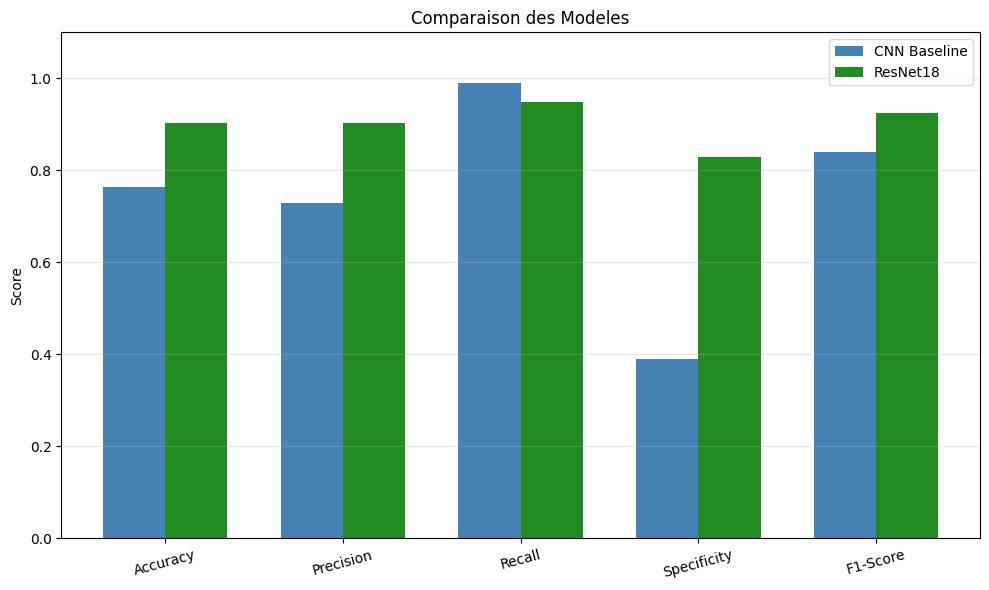

In [14]:
# Graphique comparatif
metrics = list(baseline_results.keys())
baseline_vals = list(baseline_results.values())
resnet_vals = list(resnet_results.values())

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='CNN Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, resnet_vals, width, label='ResNet18', color='forestgreen')

ax.set_ylabel('Score')
ax.set_title('Comparaison des Modeles')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/comparison_models.png', dpi=150)
plt.show()

## Resume

### Corrections appliquees:
1. **Validation set** : Split 85/15 du train (au lieu de 16 images inutilisables)
2. **Poids de classes** : `pos_weight` dans `BCEWithLogitsLoss` pour gerer le desequilibre
3. **Architecture** : Pas de Sigmoid dans le modele (plus stable numeriquement)

### Ameliorations du modele:
1. **Transfer Learning** avec ResNet18 pre-entraine
2. **Augmentation renforcee** (rotation, translation, luminosite)
3. **Early Stopping** pour eviter l'overfitting

### Resultats:
- Comparaison detaillee entre Baseline et ResNet18
- Le Transfer Learning ameliore significativement les performances